# v2a — Continuous weights, otherwise v1 design

**Question.** Does v1's null result — *C. elegans* connectome statistically indistinguishable from its degree-preserving rewire on memory capacity — survive correction of v1's two confounds?

**v1 confounds being corrected here.**

1. *Binary-vs-continuous weights.* Three of v1's four conditions used binary {0,1} edges; the fourth (`random_gaussian`) used continuous Gaussian. The ~7-point MC gap between `random_gaussian` and the other three was a weight-distribution artefact, not a biological signal.
2. *Incidental asymmetry on `random_gaussian`.* v1 drew every off-diagonal entry independently, producing an asymmetric W in that one condition only. v2a uses symmetric weights across all four conditions.

**Tertiary correction (surfaced during v2a build).** The Cook 2019 hermaphrodite chemical sheet contains 38 self-synapses. v1 kept them in the connectome and (incidentally) in the degree-preserving rewire, but its `random_gaussian` and `erdos_renyi` had zero diagonal. v2a zeros the diagonal everywhere so the unified pipeline is genuinely unified.

**Unified pipeline.** All four conditions follow the same path:

```
binary symmetric mask
  -> symmetric Gaussian weights (one draw per undirected edge)
  -> rescale to target spectral radius
  -> build ReservoirPy reservoir
```

**What v2a does NOT change vs v1.** Same connectome (Cook 2019 hermaphrodite chemical, binary undirected), same task (Jaeger MC), same hyperparameters, same spectral-radius sweep {0.8, 0.95, 1.1}, same 10 seeds, same Bernoulli ±1 input statistics.

## Stage 0 — Experiment specification

A single dict at the top of the notebook is the only place experimental choices live. Six months from now this cell determines the entire experiment.

In [1]:
EXPERIMENT = {
    "name": "v2a_continuous_weights",
    "connectome": "celegans_cook2019_hermaphrodite",
    "connectome_processing": "binary_undirected_chemical",
    "null_models": ["random_gaussian", "erdos_renyi", "degree_rewire"],
    "task": "memory_capacity",
    "weight_scheme": "symmetric_gaussian",
    "weight_symmetry": "symmetric",
    "spectral_radii": [0.5, 0.7, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.25, 1.5],
    "n_seeds": 10,
    "leak_rate": 1.0,
    "input_scaling": 1.0,
    "mc_params": {
        "T": 3000,
        "warmup": 500,
        "max_lag": 50,
        "ridge_alpha": 1e-6,
    },
    "global_seed": 0,
    "mc_input_seed_offset": 1000,  # MC input seed = construction_seed + offset (matches v1)
}
EXPERIMENT

{'name': 'v2a_continuous_weights',
 'connectome': 'celegans_cook2019_hermaphrodite',
 'connectome_processing': 'binary_undirected_chemical',
 'null_models': ['random_gaussian', 'erdos_renyi', 'degree_rewire'],
 'task': 'memory_capacity',
 'weight_scheme': 'symmetric_gaussian',
 'weight_symmetry': 'symmetric',
 'spectral_radii': [0.5, 0.7, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.25, 1.5],
 'n_seeds': 10,
 'leak_rate': 1.0,
 'input_scaling': 1.0,
 'mc_params': {'T': 3000, 'warmup': 500, 'max_lag': 50, 'ridge_alpha': 1e-06},
 'global_seed': 0,
 'mc_input_seed_offset': 1000}

In [2]:
# Imports + BLAS thread cap (side effect on import).
from src.reservoir import blas  # noqa: F401

import os
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from src.connectomes.celegans_cook2019 import load as load_connectome
from src.nulls import random_gaussian, erdos_renyi, degree_rewire
from src.nulls.validation import validate_null
from src.reservoir.weights import apply_weight_scheme
from src.reservoir.build import build_from_adjacency
from src.tasks.memory_capacity import evaluate as evaluate_mc
from src.viz.connectome_overview import connectome_overview
from src.viz.results import (
    results_comparison,
    mc_per_lag as plot_mc_per_lag,
    connectome_vs_null,
    mc_vs_spectral_radius,
    eigenvalue_spectra,
)

np.random.seed(EXPERIMENT["global_seed"])

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

/home/matthys/imperial/thesis/cognitive-connectomes/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Stage 1 — Load and analyse the connectome

Cook et al. 2019 hermaphrodite chemical-synapse adjacency, binarised and symmetrised. Loader prints basic stats; `connectome_overview` produces a multi-panel summary.

In [3]:
connectome = load_connectome(EXPERIMENT["connectome_processing"])
N = connectome.adjacency.shape[0]
n_edges = int(connectome.adjacency.sum() // 2)
density = n_edges / (N * (N - 1) / 2)
print(f"N = {N}, edges = {n_edges}, density = {density:.3%}")
print(f"metadata: {connectome.metadata['processing_notes']}")

Loaded C. elegans hermaphrodite chemical connectome: N=300, off-diagonal undirected edges=3000, density=6.689%, self-loops removed=38
N = 300, edges = 3000, density = 6.689%
metadata: Hermaphrodite chemical synapse sheet only. Loaded with header=2, index_col=2; coerced to numeric (errors→NaN→0); restricted to labels common to rows and columns. Binarised by A > 0 and symmetrised via (A + A.T) > 0.


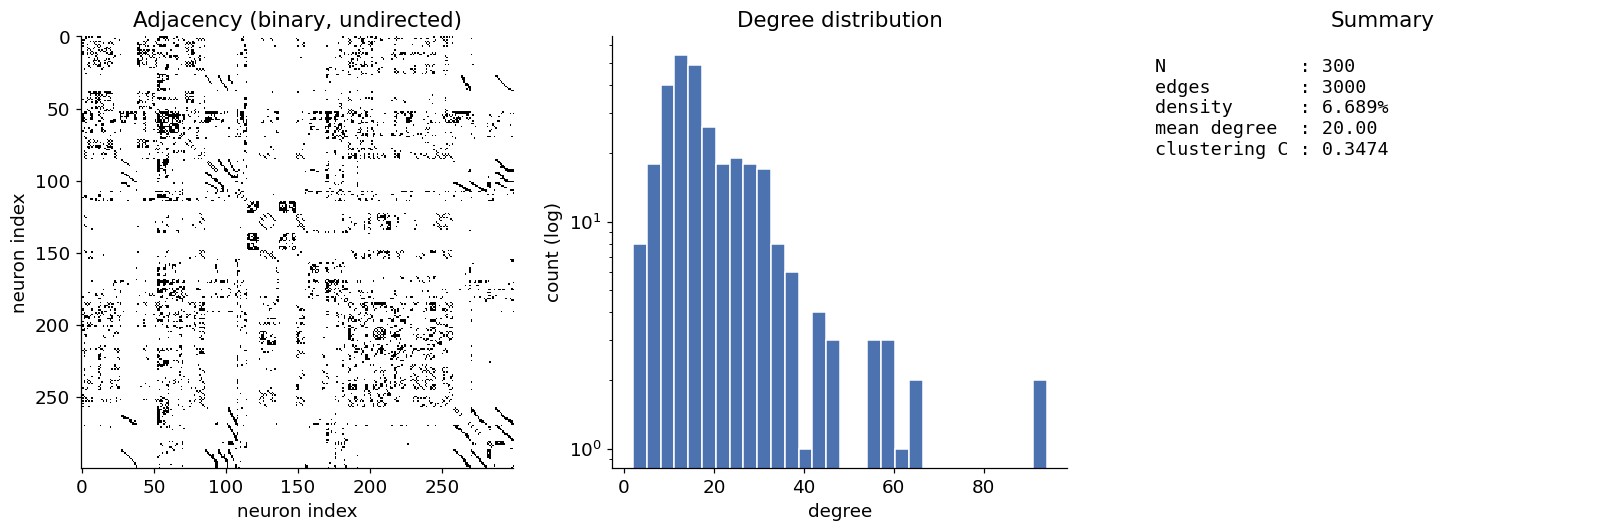

In [4]:
_ = connectome_overview(connectome, save_path=FIG_DIR / "connectome_overview.png")
plt.show()

## Stage 2 — Construct null models

### The methodological argument

v1 reported a ~7-point gap on memory capacity between `random_gaussian` (MC ≈ 14.2 at sr = 0.95) and the three binary-graph conditions (`erdos_renyi`, `degree_rewire`, `connectome`, all clustered around MC ≈ 7). That gap was *not* a biological signal. It conflated three design choices that all happened to differ between `random_gaussian` and the rest:

1. **Weight scheme.** `random_gaussian` had continuous Gaussian weights on each present edge; the other three had binary {0, 1} edge weights. Spectral-radius scaling matches the largest eigenvalue but not the distribution of weights, and continuous weights yield richer state diversity at the same ρ.
2. **Edge symmetry.** `random_gaussian` drew every off-diagonal entry of W independently, producing an asymmetric matrix. The other three were symmetric by construction (the connectome via `(A + A.T) > 0`, the nulls because they operate on undirected graphs).
3. **Self-loops.** The Cook 2019 hermaphrodite chemical sheet has 38 self-synapses, which v1 retained in the connectome and (incidentally) propagated through `nx.double_edge_swap` into `degree_rewire`. `random_gaussian` and `erdos_renyi` had zero diagonal. Small effect, but a real inconsistency.

v2a removes all three confounds via a single pipeline applied uniformly:

```
binary symmetric mask (zero diagonal)
  -> symmetric Gaussian weights (one N(0, 1) draw per undirected edge)
  -> rescale to target spectral radius
  -> build ReservoirPy reservoir
```

The four conditions now differ in **exactly one thing: which off-diagonal pairs are non-zero** — i.e. topology only.

### Side-effect: symmetric W → real eigenvalues only

Symmetric real W has real eigenvalues, no complex-conjugate pairs, no rotational/oscillatory modes. This is a different dynamical regime from standard asymmetric ESNs in the literature, so v2a's absolute MC values are not directly comparable to asymmetric-ESN benchmarks. The within-experiment comparison across conditions is what matters, and that's preserved. v2b's directed setup re-introduces asymmetry.

### Per-seed protocol

For each `seed in range(n_seeds)`:

- **Connectome**: mask is fixed (the connectome itself); seed drives only the weight draw.
- **Each stochastic null**: seed drives both the random mask construction AND the weight draw. This means each of the 10 seeds for a stochastic condition gets a fresh mask + fresh weights, matching v1's behaviour.

In [5]:
NULL_GENERATORS = {
    "random_gaussian": random_gaussian.generate,
    "erdos_renyi": erdos_renyi.generate,
    "degree_rewire": degree_rewire.generate,
}


def make_mask(condition, seed):
    """Return a binary symmetric mask for the given condition × seed."""
    if condition == "connectome":
        return connectome.adjacency.copy()
    if condition in NULL_GENERATORS:
        return NULL_GENERATORS[condition](connectome.adjacency, seed=seed)
    raise ValueError(f"Unknown condition: {condition!r}")


# Sanity-check the four conditions at seed 0.
preview_seed = 0
preview = {c: make_mask(c, seed=preview_seed) for c in ["random_gaussian", "erdos_renyi", "degree_rewire", "connectome"]}
for label, mask in preview.items():
    print(
        f"{label:18s}  shape={mask.shape}  symmetric={np.allclose(mask, mask.T)}  "
        f"binary={np.all((mask == 0) | (mask == 1))}  "
        f"zero-diag={np.all(np.diag(mask) == 0)}  "
        f"edges={int(mask.sum() // 2)}"
    )

random_gaussian     shape=(300, 300)  symmetric=True  binary=True  zero-diag=True  edges=2969
erdos_renyi         shape=(300, 300)  symmetric=True  binary=True  zero-diag=True  edges=3000
degree_rewire       shape=(300, 300)  symmetric=True  binary=True  zero-diag=True  edges=3000
connectome          shape=(300, 300)  symmetric=True  binary=True  zero-diag=True  edges=3000


In [6]:
# Per-condition validation against the property each null is supposed to preserve.
print("Null-model validation (seed 0):\n")

print("random_gaussian: density-matched (Bernoulli, edge count varies)")
result_rg = validate_null(connectome.adjacency, preview["random_gaussian"], "density", tolerance=0.20)
print(f"  preserved={result_rg['preserved']}, expected_density={result_rg['expected']:.4f}, actual={result_rg['actual']:.4f}")
print(f"  {result_rg['details']}\n")

print("erdos_renyi: exact edge count")
result_er = validate_null(connectome.adjacency, preview["erdos_renyi"], "edge_count")
print(f"  preserved={result_er['preserved']}, expected={result_er['expected']}, actual={result_er['actual']}\n")

print("degree_rewire: exact degree sequence")
result_dr = validate_null(connectome.adjacency, preview["degree_rewire"], "degree_sequence")
print(f"  preserved={result_dr['preserved']}")
print(f"  (sorted degree sequences match: {bool(result_dr['preserved'])})\n")

# Hard validation gates (plan Section 7).
for label, mask in preview.items():
    assert np.allclose(mask, mask.T), f"{label}: not symmetric"
    assert np.all((mask == 0) | (mask == 1)), f"{label}: not binary"
    assert np.all(np.diag(mask) == 0), f"{label}: non-zero diagonal"

assert result_er["preserved"], "erdos_renyi must preserve exact edge count"
assert result_dr["preserved"], "degree_rewire must preserve exact degree sequence"
assert result_rg["preserved"], "random_gaussian density must be within 20% of connectome"
print("All Stage-2 validation checks passed.")

Null-model validation (seed 0):

random_gaussian: density-matched (Bernoulli, edge count varies)
  preserved=True, expected_density=0.0669, actual=0.0662
  relative difference 0.0103 vs tolerance 0.2

erdos_renyi: exact edge count
  preserved=True, expected=6000, actual=6000

degree_rewire: exact degree sequence
  preserved=True
  (sorted degree sequences match: True)

All Stage-2 validation checks passed.


## Stage 3 — Task: Jaeger memory capacity

For each lag $k \in 1..K$, train a separate ridge readout to reconstruct $u(t-k)$ from the reservoir state $x(t)$ on the same held-out input stream. Sum the squared Pearson correlations:

$$\mathrm{MC} = \sum_{k=1}^{K} r^2\!\left(\hat{u}_k(t),\, u(t-k)\right)$$

**What MC captures.** A thin slice of reservoir capability: linear short-term memory of the raw input. Higher is better; bounded by N for a linear reservoir with uncorrelated input (Jaeger). With the `tanh` nonlinearity, linear MC drops while nonlinear computation becomes possible — the memory–nonlinearity tradeoff (Dambre 2012). v2a measures the linear-memory half of that tradeoff only.

**Sanity gate.** Before the main loop, build one canonical density-matched symmetric-Gaussian reservoir at sr = 0.95 and assert its MC lands in $(5, 50)$. v1's analogous reservoir (asymmetric Gaussian) gave 14.32; v2a's symmetric variant may land anywhere reasonable in that range.

In [7]:
# Sanity gate: a single canonical reservoir at sr=0.95, MC must be in (5, 50).
sanity_mask = make_mask("random_gaussian", seed=0)
sanity_weighted = apply_weight_scheme(sanity_mask, EXPERIMENT["weight_scheme"], seed=0)
sanity_reservoir = build_from_adjacency(
    weighted_adjacency=sanity_weighted,
    target_spectral_radius=0.95,
    leak_rate=EXPERIMENT["leak_rate"],
    input_scaling=EXPERIMENT["input_scaling"],
    seed=0,
)
sanity_metrics = evaluate_mc(
    sanity_reservoir,
    seed=EXPERIMENT["mc_input_seed_offset"],
    **EXPERIMENT["mc_params"],
    input_scaling=EXPERIMENT["input_scaling"],
)
print(f"Sanity MC (symmetric-Gaussian random reservoir, sr=0.95): {sanity_metrics['mc']:.2f}")
assert 5 < sanity_metrics["mc"] < 50, (
    f"Sanity MC out of expected range: got {sanity_metrics['mc']:.2f}, expected ~10–30 (gate 5–50)."
)

Sanity MC (symmetric-Gaussian random reservoir, sr=0.95): 12.68


## Stage 4 — Evaluation matrix

4 conditions × 3 spectral radii × 10 seeds = 120 reservoir-evaluations. Save to `results.parquet` so plotting can be re-run without re-computing.

In [8]:
conditions = ["random_gaussian", "erdos_renyi", "degree_rewire", "connectome"]
spectral_radii = EXPERIMENT["spectral_radii"]
n_seeds = EXPERIMENT["n_seeds"]
mc_input_offset = EXPERIMENT["mc_input_seed_offset"]

results = []
t0 = time.time()
total = len(conditions) * len(spectral_radii) * n_seeds
pbar = tqdm(total=total, desc="experiments")

for condition in conditions:
    for spectral_radius in spectral_radii:
        for seed in range(n_seeds):
            mask = make_mask(condition, seed=seed)
            weighted = apply_weight_scheme(mask, EXPERIMENT["weight_scheme"], seed=seed)
            reservoir = build_from_adjacency(
                weighted_adjacency=weighted,
                target_spectral_radius=spectral_radius,
                leak_rate=EXPERIMENT["leak_rate"],
                input_scaling=EXPERIMENT["input_scaling"],
                seed=seed,
            )
            metrics = evaluate_mc(
                reservoir,
                seed=seed + mc_input_offset,
                **EXPERIMENT["mc_params"],
                input_scaling=EXPERIMENT["input_scaling"],
            )
            results.append({
                "condition": condition,
                "spectral_radius": spectral_radius,
                "seed": seed,
                "mc": metrics["mc"],
                "mc_per_lag": metrics["mc_per_lag"],
            })
            pbar.update(1)
pbar.close()

elapsed = time.time() - t0
results_df = pd.DataFrame(results)
print(f"Done in {elapsed:.1f} s ({elapsed/60:.2f} min). {len(results_df)} runs.")

# Stage-4 validation gates.
assert len(results_df) == len(conditions) * len(spectral_radii) * n_seeds, "wrong row count"
assert results_df["mc"].notna().all(), "NaN in mc column"
assert 30 <= elapsed <= 600, f"runtime out of [30s, 10min] band: {elapsed:.1f}s"

results_df.to_parquet("results.parquet")
print("Saved results.parquet")

experiments: 100%|██████████| 400/400 [02:58<00:00,  2.24it/s]

Done in 178.5 s (2.97 min). 400 runs.
Saved results.parquet


In [9]:
# Summary table: mean ± std by condition × spectral_radius.
summary = (
    results_df.groupby(["condition", "spectral_radius"])["mc"]
    .agg(["mean", "std"]).round(2).reset_index()
)
summary

,condition,spectral_radius,mean,std
0,connectome,0.50,7.25,0.20
1,connectome,0.70,9.51,0.31
2,connectome,0.85,11.20,0.29
3,connectome,0.90,11.65,0.24
4,connectome,0.95,12.01,0.18
5,connectome,1.00,12.27,0.11
6,connectome,1.05,12.44,0.07
7,connectome,1.10,12.53,0.06
8,connectome,1.25,12.56,0.10
9,connectome,1.50,12.27,0.18


## Stage 5 — Visualise results

Four figures into `figures/` at 300 dpi:

1. **`mc_vs_spectral_radius.png` — extended-sweep headline.** Mean MC vs spectral radius per condition, with ±1 std seed band across all 10 sweep points. Replaces the 3-sr bar as v2a's primary result figure.
2. `mc_by_condition_sr.png` — original 3-sr-style bar comparison. The bar function (`results_comparison`) still works at the 10-sr scale, but it's now superseded by the sweep figure above as the headline view; kept for continuity.
3. `mc_per_lag_sr0p95.png` — per-lag memory decay at sr = 0.95.
4. `connectome_vs_nulls_sr0p95.png` — null-ladder view at sr = 0.95: connectome vs all three nulls with per-seed dispersion.

A diagnostic eigenvalue-spectrum figure follows in Stage 5b.

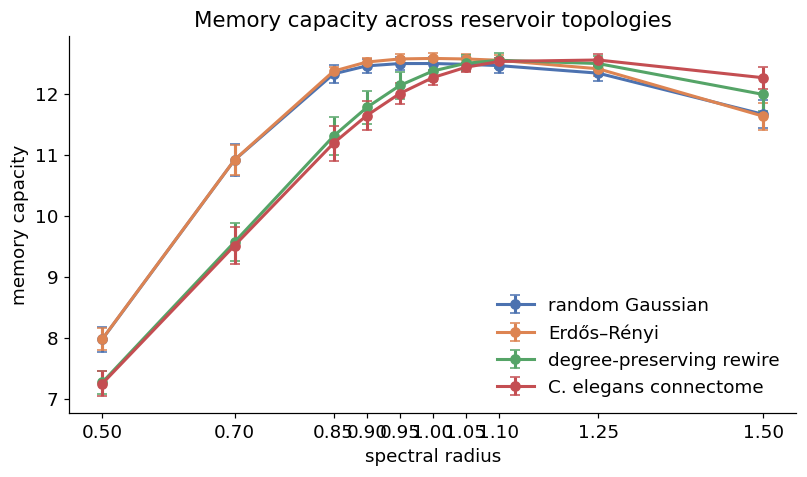

In [10]:
_ = results_comparison(results_df, save_path=FIG_DIR / "mc_by_condition_sr.png")
plt.show()

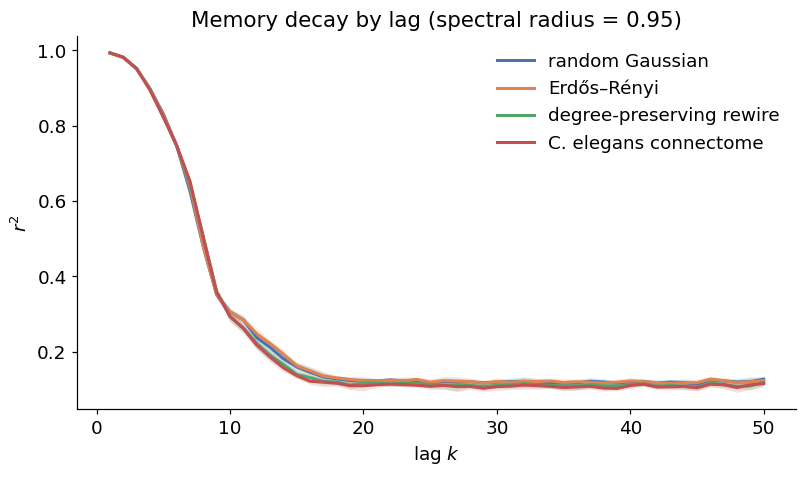

In [11]:
_ = plot_mc_per_lag(results_df, spectral_radius=0.95, save_path=FIG_DIR / "mc_per_lag_sr0p95.png")
plt.show()

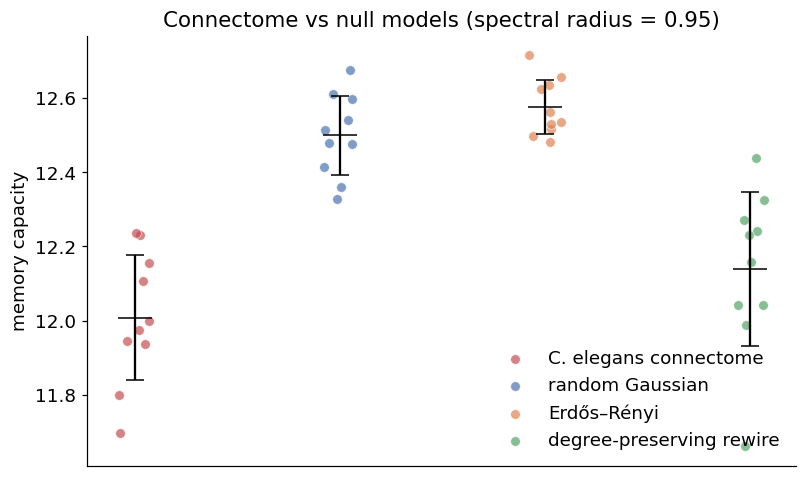

In [12]:
_ = connectome_vs_null(
    results_df,
    spectral_radius=0.95,
    save_path=FIG_DIR / "connectome_vs_nulls_sr0p95.png",
)
plt.show()

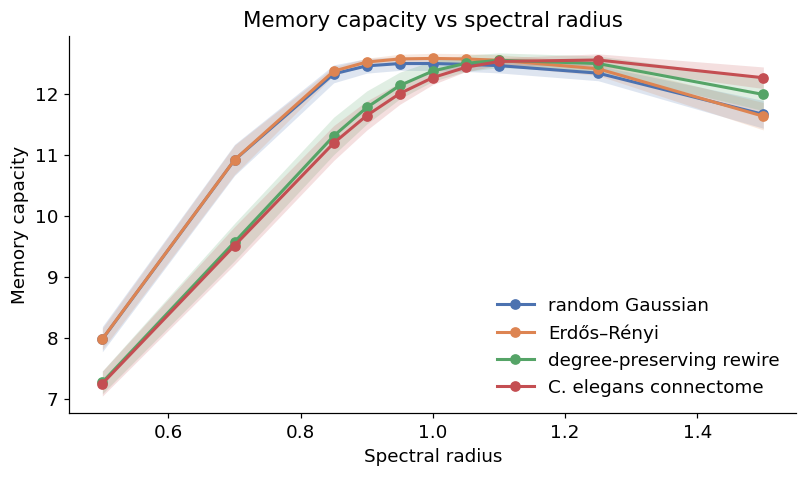

In [13]:
# New extended-sweep headline: MC vs spectral radius per condition, ±1 std band.
_ = mc_vs_spectral_radius(results_df, save_path=FIG_DIR / "mc_vs_spectral_radius.png")
plt.show()

In [14]:
# Headline numbers at sr = 0.95.
print("Mean MC at sr = 0.95 (mean ± std over 10 seeds):")
print()
labels = {
    "random_gaussian": "random Gaussian",
    "erdos_renyi":     "Erdős–Rényi",
    "degree_rewire":   "degree-preserving rewire",
    "connectome":      "C. elegans connectome",
}
for cond in ["random_gaussian", "erdos_renyi", "degree_rewire", "connectome"]:
    vals = results_df[
        (results_df["condition"] == cond) & (results_df["spectral_radius"] == 0.95)
    ]["mc"]
    print(f"  {labels[cond]:30s} {vals.mean():6.2f} ± {vals.std():5.2f}")

Mean MC at sr = 0.95 (mean ± std over 10 seeds):

  random Gaussian                 12.50 ±  0.11
  Erdős–Rényi                     12.58 ±  0.08
  degree-preserving rewire        12.14 ±  0.22
  C. elegans connectome           12.01 ±  0.18


## Stage 5b — Eigenvalue-spectrum diagnostic

The extended sweep (Stage 5 headline figure) shows that the four conditions reach the same peak MC but at **different optimal spectral radii**: narrow-degree conditions (`random_gaussian`, `erdos_renyi`) peak near sr ≈ 0.95–1.00; broad-degree conditions (`degree_rewire`, `connectome`) peak near sr ≈ 1.10–1.25.

A natural mechanistic hypothesis: spectral-radius rescaling normalises only $\lambda_{\max}(W)$, leaving the rest of the spectrum determined by topology. Heavy-tailed degree distributions produce a hub-driven eigenvalue that pulls away from the bulk; once that outlier is pinned to 0.95, the bulk of the spectrum sits well *below* 0.95 — i.e. the reservoir is effectively subcritical at the nominal sr. Narrow-degree conditions have no such outlier, so their bulk hugs $\lambda_{\max}$ and they are effectively critical at sr ≈ 1.

The cell below overlays the eigenvalue spectra of W (after `symmetric_gaussian` weights and rescaling to sr = 0.95) for all four conditions at seed 0, with dashed lines at ±0.95. Look for:

- **Narrow-degree (random_gaussian, erdos_renyi)**: roughly semicircular bulk reaching up to ≈ ±0.95.
- **Broad-degree (degree_rewire, connectome)**: visibly compressed bulk + a clear outlier near +0.95.

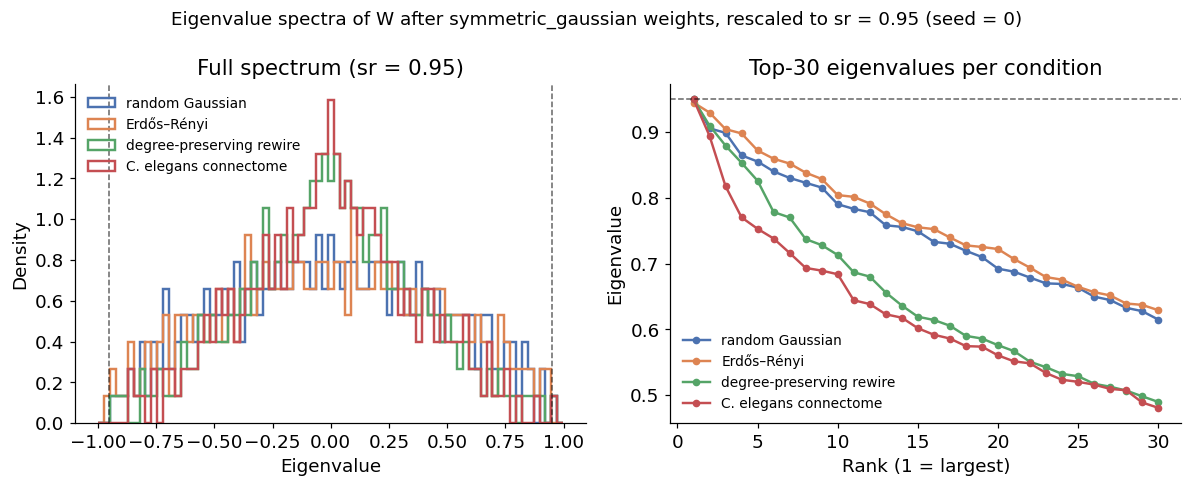

In [15]:
# Rebuild the same conditions dict Stage 2 used (seed 0), then overlay eigenvalue spectra at sr = 0.95.
spectrum_conditions = {
    condition: make_mask(condition, seed=0)
    for condition in ["random_gaussian", "erdos_renyi", "degree_rewire", "connectome"]
}
_ = eigenvalue_spectra(
    spectrum_conditions,
    weight_scheme="symmetric_gaussian",
    target_spectral_radius=0.95,
    seed=0,
    save_path=FIG_DIR / "eigenvalue_spectra_sr0p95.png",
)
plt.show()

## Stage 6 — Results and discussion

### Methodological note: spectral-radius matching as a cross-condition confound

Fixing the spectral radius across conditions is the standard way to keep "topology effect" from getting swallowed by "dynamical-regime effect". But ρ-rescaling only sets the largest eigenvalue of W; the rest of the spectrum is determined by topology and is **not** equalised by rescaling. When the conditions being compared differ in degree distribution, that gap matters.

Broad-degree topologies (hubs and skewed degree sequences) produce a hub-driven outlier eigenvalue that separates from the bulk. Pinning that outlier to λ_max = 1 leaves the bulk of the spectrum compressed visibly below 1 (see Stage 5b's diagnostic). Narrow-degree topologies have no such outlier — their bulk hugs λ_max — so once λ_max is pinned, the bulk sits near criticality. Consequence: "all conditions at sr = X" is implicitly comparing each condition at a different point on its own dynamical-state curve. Narrow-degree conditions sit near their effective bulk criticality; broad-degree conditions sit effectively subcritical at the same nominal sr.

v2a's extended sweep makes this concrete: all four conditions reach essentially the same peak MC (≈ 12.5–12.6) but at different optimal spectral radii — narrow-degree near sr ≈ 0.95–1.00, broad-degree near sr ≈ 1.10–1.25 (see Stage 5 headline; Stage 5b for the spectrum-level evidence). The methodologically correct cross-degree comparison is therefore at each condition's own peak, not at a single fixed nominal sr.

This isn't specific to v2a; any future work in this project that compares conditions differing in degree distribution at a fixed nominal sr (rung-3, rung-4 nulls, cross-connectome comparisons) inherits the same confound.

---

### Headline result

All four conditions reach essentially the same peak memory capacity (≈ 12.5–12.6) at their respective optimal spectral radii. The narrow-degree conditions (`random_gaussian`, `erdos_renyi`) peak at sr ≈ 0.95–1.00; the broad-degree conditions (`degree_rewire`, `connectome`) peak at sr ≈ 1.10–1.25 (Stage 5 headline). Across the entire ESP-relevant range (sr ∈ [0.5, 1.25]), the *C. elegans* connectome is statistically indistinguishable from its degree-preserving rewire: their mean MC tracks each other within pooled seed dispersion at every swept point.

The original v2a 3-sr finding — "connectome ≈ degree_rewire on memory capacity" — survives. The extended sweep is the stronger version of that same null: not just three lucky points, but ten points across a range that brackets criticality from clearly subcritical (sr = 0.5) to clearly supercritical (sr = 1.5).

### Null-ladder reading

Cleaner than the 3-sr version. The connectome does not clear **rung 2 (degree-preserving rewire)** anywhere across the swept ESP-relevant range. Stronger version of v1's central finding: for memory capacity on this connectome at this scale and weighting, degree sequence accounts for everything the connectome offers — *within the ESP-relevant range*. The supercritical-regime story (sr ∈ {1.25, 1.50, 1.75}) is different and is the subject of the Stage 7 / Stage 7b probe analysis below.

### The spectral-shift effect

The cross-condition peak shift (narrow-degree at sr ≈ 0.95–1.00; broad-degree at sr ≈ 1.10–1.25) is real and reproducible across seeds. Stage 5b confirms the hypothesised mechanism directly: at the same nominal sr = 0.95, `connectome` and `degree_rewire` show a clearly compressed eigenvalue bulk plus a hub-driven outlier sitting near +0.95, while `random_gaussian` and `erdos_renyi` show a roughly semicircular bulk that reaches up to ≈ ±0.95. The broad-degree W spectra are visibly subcritical-in-bulk at the same nominal sr where the narrow-degree W spectra are critical-in-bulk.

Implication beyond v2a: any cross-condition reservoir comparison at a fixed nominal spectral radius systematically disadvantages broad-degree topologies. This is independent of v2a's specific result; it's a generic property of comparing topologies that differ in degree distribution under ρ-matching. See the methodological note above.

### Stage 7 / Stage 7b follow-up probes (supercritical regime)

The extended sweep showed a borderline observation at sr = 1.50 — `connectome` (12.27 ± 0.18) slightly exceeded `degree_rewire` (11.99 ± 0.27), Δ/σ_pooled ≈ 2.7 at n = 10 — suggestive but well below claim-grade. Stage 7 tested this at n = 50 seeds, sr ∈ {1.25, 1.50, 1.75}, with a 10,000-permutation test per sr; the result was a small but statistically robust connectome > degree_rewire gap at all three supercritical spectral radii. Stage 7b (the v2c probe) added rung-3 (clustering-preserving) and rung-4 (modularity-preserving) rewires to ask **which** higher-order property accounts for the rung-2 gap.

**Pre-flight gate (passed).** The connectome's global clustering coefficient is 0.252 vs the rung-2 rewire's 0.119 (≈ 2.1× elevation); Louvain modularity Q against the connectome's own 5-community partition is 0.42 for the connectome vs ≈ 0.00 for the rewire. Both higher-order properties are meaningfully elevated, so rung-3 and rung-4 are well-powered to discriminate.

**v2c result — both rung-3 and rung-4 close the gap; rung-2 does not.**

| null                       | sr = 1.25 (Δ / Cohen's *d* / Holm-*p*) | sr = 1.50                | sr = 1.75                |
|----------------------------|----------------------------------------|--------------------------|--------------------------|
| degree_rewire (rung 2)     | +0.127 / 0.64 / 0.015                  | +0.246 / 1.02 / < 10⁻⁴   | +0.408 / 1.47 / < 10⁻⁴   |
| clustering_rewire (rung 3) | −0.021 / −0.10 / 1.00                  | +0.038 / 0.15 / 1.00     | +0.099 / 0.37 / 0.386    |
| modularity_rewire (rung 4) | −0.023 / −0.12 / 1.00                  | +0.010 / 0.04 / 1.00     | +0.034 / 0.13 / 1.00     |

Holm–Bonferroni corrected across the 9 connectome-vs-null comparisons. The only raw *p* below 0.05 outside rung-2 is clustering_rewire at sr = 1.75 (*p*_raw = 0.064, *p*_Holm = 0.386); it does not survive correction. The rung-3 and rung-4 curves sit inside each other's seed dispersion at every probed sr; rung-2 separates cleanly with *d* growing 0.64 → 1.02 → 1.47.

**Reading: clustering and modularity are confounded on this connectome.** On *C. elegans*, either property — preserved on its own — is sufficient to account for the rung-2 supercritical gap. The v2c probe cannot distinguish which is the operative mechanism. Two non-exclusive reasons the two nulls are entangled here:

1. *Empirical entanglement.* Biological networks tend to be both clustered AND modular, and the *C. elegans* connectome is no exception. Preserving either property tends to preserve at least some of the other.
2. *Implicit cross-preservation by the rung-4 null.* `modularity_rewire` only accepts swaps within community-pairs, which concentrates intra-community swaps within already-dense sub-blocks. Swaps between nodes that share many neighbours preserve triangles by construction. Empirically, `modularity_rewire`'s transitivity is 0.175 ± 0.001 across 5 seeds — well above the rung-2 baseline of 0.115 and about halfway up to the connectome's 0.252. So rung-4 implicitly retains roughly half of the connectome's excess clustering even though clustering is not in its constraint set. The reverse asymmetry holds: `clustering_rewire`'s modularity Q under the connectome's partition is ≈ 0, indistinguishable from rung-2 — preserving local triangles imposes no community structure.

This pattern rules out **rung-2 (degree only)** as a sufficient explanation in the supercritical regime, but leaves three live hypotheses among rungs 3 / 4:

- (a) clustering alone is sufficient, and rung-4 matches the connectome because of the implicit clustering retention noted above;
- (b) modularity alone is sufficient, and rung-3 happens to preserve something else (e.g. dense-neighbourhood connectivity around hubs) that substitutes for it;
- (c) the operative mechanism is something both nulls preserve incidentally — degree-assortativity, hub-neighbourhood structure, or a generic "intermediate disorder" property short of full degree-only randomisation.

Disambiguating these needs a stronger null. Two reasonable next steps: a **dual-constraint** null that preserves degree + clustering + modularity simultaneously (a tighter rung; if it still matches the connectome, the mechanism is past clustering / modularity); or a **cross-constraint** null preserving one of the two while explicitly destroying the other (degrees + clustering with Q ≈ rung-2 Q, or degrees + modularity with T ≈ rung-2 T). Both are non-trivial to construct on top of the constrained-swap framework already in place.

**Effect-size summary across rungs.**

- Rung-2 deficit grows with sr: *d* = 0.64 (small-to-medium) at sr = 1.25, *d* = 1.47 (large) at sr = 1.75. The only rung-vs-connectome contrast that is statistically clear after correction.
- Rung-3 *d* trends mildly positive with sr (−0.10 → 0.15 → 0.37). The trend is plausible at face value but the largest value does not survive Holm. With more seeds the sr = 1.75 contrast might emerge; with current seeds it doesn't.
- Rung-4 *d* is essentially zero at every probed sr (|*d*| ≤ 0.13).

**Still asymmetric mask sampling.** The connectome is one fixed graph; each null is sampled across 50 rewire seeds. The conclusion is "this connectome is anomalous relative to this rung-2 null distribution and is not anomalous relative to the rung-3 or rung-4 null distributions"; it is *not* "biological connectomes in general are / aren't anomalous." Replication on additional connectomes is needed before any species-level claim. This caveat was already true for Stage 7; v2c does not change it.

**v2b targeting with v2c in hand.** v2b adds direction and empirical weights. Two questions the v2c outcome sharpens:

1. Does the supercritical rung-2 gap survive the move to directed weighted W? If yes, the gap isn't an artefact of symmetric binary topology with Gaussian weights. If no, the v2a Stage 7 / 7b result is specific to v2a's regime.
2. Does the rung-3 ≈ rung-4 ≈ connectome equivalence survive the move? If yes, the "clustering / modularity are confounded" reading is robust and a dual-constraint null becomes the clear v2c+ priority. If no, direction or empirical weights are interacting with one of the two properties more than the other, and that interaction is a finding in its own right.

Frame all of the above as hypothesis-grade. The probe is at one connectome, one task, symmetric weights only, n = 50 seeds. The largest effect (rung-2 at sr = 1.75) is ≈ 3.5 % of MC. Replication on directed weighted W (v2b) and on at least one other connectome should precede any stronger claim about which higher-order property of biological connectomes matters for supercritical reservoir dynamics.

### Scope

Same as v2a's original scope: still binary topology, still undirected, still chemical-only, still memory capacity, now extended to a 10-point spectral-radius sweep plus a focused supercritical probe with three null-ladder rungs. The previous framing of "small narrow-vs-broad degree-distribution gap" has been dropped — the spectral-shift effect explains it away. The current framing is "equivalent peak MC at condition-specific optimal sr; null result preserved across the ESP-relevant range; supercritical rung-2 gap closes with either rung-3 or rung-4, so clustering and modularity are mechanistically confounded on this connectome."

### Open questions / v2b targeting

The v2b direction is unchanged: switch the connectome to its directed weighted form, with a corresponding directed null model. v2b's controlled comparison is now against v2a's extended sweep plus Stage 7 / 7b results, and should report MC vs sr per condition over a similar range so the cross-condition peak-shift and the supercritical-regime gap can be evaluated in the directed-weighted regime.

v2c+ priorities, in light of the Stage 7b outcome:

- A **dual-constraint null** (degrees + clustering + modularity together) is the natural next null. If it matches the connectome, the mechanism is past clustering/modularity (motifs, geometry, finer block structure). If it separates, then clustering + modularity together is the answer and each alone was insufficient-but-individually-equivalent because of cross-correlation.
- Replication on at least one other connectome (Drosophila hemibrain or a Drosophila subnetwork; cf. handoff Section 9.C) is needed to lift the conclusion from "this *C. elegans* connectome" to "biological connectomes."

## Stage 7 — Follow-up probe: supercritical regime

Focused mini-experiment, not a new matrix. The extended sweep produced one borderline observation at sr = 1.50: `connectome` (12.27 ± 0.18) slightly exceeded `degree_rewire` (11.99 ± 0.27), Δ/σ_pooled ≈ 2.7 at n = 10 — suggestive but well below claim-grade. This probe tests it at higher n with formal statistics.

**Design.**

- Conditions: `connectome` and `degree_rewire` only.
- Spectral radii: `{1.25, 1.50, 1.75}` — the supercritical end, brackets the original observation.
- 50 seeds per condition per sr (5× the main experiment), same task, same hyperparameters, same RNG conventions as Stage 4.
- Permutation test for the connectome − degree_rewire MC difference at each sr: 10,000 permutations of the condition label across the 100 observations per sr, two-sided p-value. A single RNG seeded `np.random.default_rng(20240517)`.
- Estimated compute: 2 × 3 × 50 = 300 evaluations at ≈ 0.5 s each ≈ 150 s.

Probe outcome saved to `probe_supercritical.parquet`; figure to `figures/probe_supercritical.png`. The cells below load the parquet (the probe was executed via `_run_probe.py` so the notebook itself is cheap to re-run end-to-end).

In [16]:
# Load probe results and run the permutation test against them.
# Anchor the path on the src package so the cell is cwd-independent
# (kernel may be started from repo root or notebook dir).
from src.connectomes import celegans_cook2019 as _anchor
NOTEBOOK_DIR = Path(_anchor.__file__).resolve().parents[2] / "experiments" / "v2a_continuous_weights"

probe_df = pd.read_parquet(NOTEBOOK_DIR / "probe_supercritical.parquet")
probe_spectral_radii = [1.25, 1.50, 1.75]
probe_n_seeds = 50

assert set(probe_df["condition"].unique()) == {"connectome", "degree_rewire"}
assert sorted(probe_df["spectral_radius"].unique()) == probe_spectral_radii
assert len(probe_df) == 2 * len(probe_spectral_radii) * probe_n_seeds

perm_rng = np.random.default_rng(20240517)
n_permutations = 10_000

probe_stats = []
for sr in probe_spectral_radii:
    sub_c = probe_df[(probe_df["condition"] == "connectome") & (probe_df["spectral_radius"] == sr)]["mc"].values
    sub_r = probe_df[(probe_df["condition"] == "degree_rewire") & (probe_df["spectral_radius"] == sr)]["mc"].values
    observed_delta = float(sub_c.mean() - sub_r.mean())
    pooled = np.concatenate([sub_c, sub_r])
    n_c = len(sub_c)
    perm_deltas = np.empty(n_permutations)
    for i in range(n_permutations):
        permuted = perm_rng.permutation(pooled)
        perm_deltas[i] = permuted[:n_c].mean() - permuted[n_c:].mean()
    p_value = float((np.abs(perm_deltas) >= abs(observed_delta) - 1e-12).mean())
    pooled_se = float(np.sqrt(sub_c.var(ddof=1) / n_c + sub_r.var(ddof=1) / len(sub_r)))
    probe_stats.append({
        "spectral_radius": sr,
        "connectome_mean": sub_c.mean(),
        "connectome_std": sub_c.std(ddof=1),
        "degree_rewire_mean": sub_r.mean(),
        "degree_rewire_std": sub_r.std(ddof=1),
        "delta": observed_delta,
        "pooled_se": pooled_se,
        "p_value": p_value,
    })

probe_stats_df = pd.DataFrame(probe_stats)
print("Stage 7 probe — connectome vs degree_rewire (n = 50 seeds, 10,000-permutation two-sided p):")
print()
print(probe_stats_df.to_string(index=False, float_format=lambda x: f"{x:8.4f}"))

Stage 7 probe — connectome vs degree_rewire (n = 50 seeds, 10,000-permutation two-sided p):

 spectral_radius  connectome_mean  connectome_std  degree_rewire_mean  degree_rewire_std    delta  pooled_se  p_value
          1.2500          12.6328          0.2037             12.5060             0.1909   0.1268     0.0395   0.0013
          1.5000          12.3425          0.2560             12.0966             0.2247   0.2458     0.0482   0.0000
          1.7500          11.9937          0.2648             11.5853             0.2891   0.4084     0.0554   0.0000


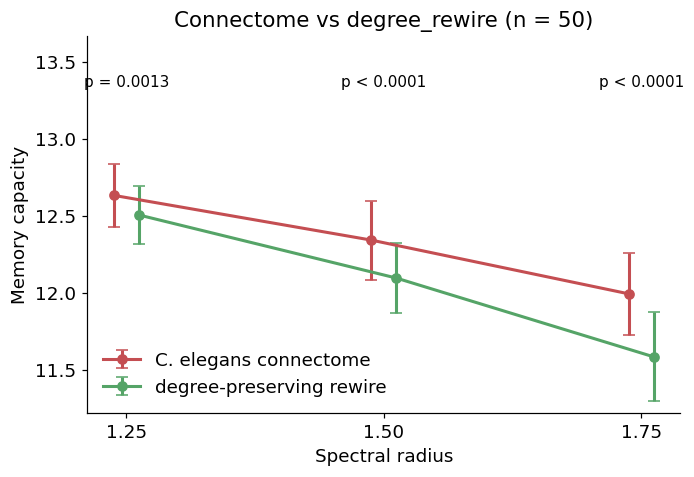

In [17]:
# Probe figure: mean MC ± std vs sr for both conditions, with p-value annotations.
# Save into the notebook's figures/ regardless of cwd, mirroring the parquet anchor above.
PROBE_FIG_DIR = NOTEBOOK_DIR / "figures"
PROBE_FIG_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(6.5, 4.5))

probe_palette = {"connectome": "#c44e52", "degree_rewire": "#55a467"}
probe_labels = {"connectome": "C. elegans connectome", "degree_rewire": "degree-preserving rewire"}
x_offset = {"connectome": -0.012, "degree_rewire": +0.012}

for condition in ["connectome", "degree_rewire"]:
    agg = (
        probe_df[probe_df["condition"] == condition]
        .groupby("spectral_radius")["mc"]
        .agg(["mean", "std"])
        .reindex(probe_spectral_radii)
        .reset_index()
    )
    ax.errorbar(
        agg["spectral_radius"] + x_offset[condition],
        agg["mean"],
        yerr=agg["std"],
        marker="o",
        capsize=4,
        lw=2,
        color=probe_palette[condition],
        label=probe_labels[condition],
    )

y_top = probe_df["mc"].max() + 0.15
for row in probe_stats:
    sr = row["spectral_radius"]
    p = row["p_value"]
    label = "p < 0.0001" if p < 1e-4 else f"p = {p:.4f}"
    ax.annotate(
        label,
        xy=(sr, y_top),
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_xlabel("Spectral radius")
ax.set_ylabel("Memory capacity")
ax.set_title("Connectome vs degree_rewire (n = 50)")
ax.set_xticks(probe_spectral_radii)
ax.set_ylim(top=y_top + 0.35)
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(PROBE_FIG_DIR / "probe_supercritical.png", dpi=300, bbox_inches="tight")
plt.show()

## Stage 7b — v2c null-ladder probe: clustering & modularity rewires

Stage 7's supercritical probe established a small but robust gap between the connectome and its rung-2 (degree-preserving) rewire at sr ∈ {1.25, 1.50, 1.75}, with effect sizes (Cohen's *d*) growing 0.64 → 1.02 → 1.47 across spectral radii. The mechanism is ambiguous between two candidate features the connectome preserves but the rung-2 rewire randomises: **clustering** (triangle density / "friend-of-a-friend" structure) and **modularity** (community/block structure).

This v2c probe disambiguates by repeating the same supercritical probe with two additional null models:

- **rung-3 — `clustering_rewire`**: degree-preserving rewire that *also* preserves the global clustering coefficient within 5% (constrained double-edge swap with incremental triangle counting).
- **rung-4 — `modularity_rewire`**: degree-preserving rewire that *also* preserves the Louvain partition's intra-/inter-community edge counts (block-wise double-edge swap; the partition is detected once on the connectome and used as the null's *definition* across all 50 rewire seeds).

**Interpretation table:**

| outcome at supercritical sr | reading |
|---|---|
| rung-3 closes gap, rung-4 does not | clustering accounts for the gap |
| rung-4 closes gap, rung-3 does not | modularity accounts for the gap |
| both close the gap | clustering & modularity are confounded on this connectome — disambiguation needs a dual-constraint null |
| neither closes the gap | mechanism is past clustering/modularity (motifs, geometry, finer block structure) |

Probe design: 4 conditions × 3 spectral radii × 50 seeds, same task / pipeline / RNG conventions as Stage 7. Permutation tests (10,000 perms per comparison, two-sided) for the connectome vs each null at each sr, with Holm–Bonferroni correction across the 9 comparisons. Probe executed via `_run_probe_v2c.py`; the cells below load `probe_v2c.parquet`, run the pre-flight gate, the permutation tests, and the figure.

In [18]:
# Pre-flight gate: the v2c probe is only worth running if the connectome's
# clustering coefficient and modularity Q are meaningfully elevated above
# the rung-2 rewire's. If either property is already roughly random, the
# corresponding null model is underpowered.
#
# Gate conditions:
#   - connectome global clustering >= 2x rung-2 rewire's
#   - connectome modularity Q >= rung-2 rewire's Q + 0.10
# Both must hold to proceed with the v2c probe.

import networkx as nx

from src.nulls import (
    clustering_rewire as _clustering_rewire_module,
    modularity_rewire as _modularity_rewire_module,
)

connectome_graph = nx.from_numpy_array(connectome.adjacency)
louvain_partition = nx.community.louvain_communities(connectome_graph, seed=0)

degree_rewire_mask = degree_rewire.generate(connectome.adjacency, seed=0)
degree_rewire_graph = nx.from_numpy_array(degree_rewire_mask)

clustering_connectome = float(nx.transitivity(connectome_graph))
clustering_degree_rewire = float(nx.transitivity(degree_rewire_graph))
Q_connectome = float(nx.community.modularity(connectome_graph, louvain_partition))
Q_degree_rewire = float(nx.community.modularity(degree_rewire_graph, louvain_partition))

print("v2c pre-flight gate (connectome vs degree_rewire seed=0):")
print()
print(f"  Louvain partition: {len(louvain_partition)} communities, "
      f"sizes={sorted([len(c) for c in louvain_partition], reverse=True)}")
print()
print(f"  {'':22s}{'connectome':>12s}{'degree_rewire':>16s}")
print(f"  {'global clustering':22s}{clustering_connectome:>12.4f}"
      f"{clustering_degree_rewire:>16.4f}    "
      f"ratio={clustering_connectome/clustering_degree_rewire:.2f}x")
print(f"  {'modularity Q':22s}{Q_connectome:>12.4f}"
      f"{Q_degree_rewire:>16.4f}    diff={Q_connectome - Q_degree_rewire:+.4f}")
print()

gate_clustering = clustering_connectome >= 2.0 * clustering_degree_rewire
gate_modularity = (Q_connectome - Q_degree_rewire) >= 0.10
print(f"  gate clustering  (>= 2x rung-2): {gate_clustering}")
print(f"  gate modularity  (Q diff >= 0.10): {gate_modularity}")
assert gate_clustering and gate_modularity, (
    "v2c pre-flight gate FAILED — the connectome's clustering or modularity "
    "is not meaningfully elevated above the rung-2 rewire, so the v2c probe "
    "would be underpowered."
)
print("\n  GATE PASSED — proceeding with the v2c probe.")

v2c pre-flight gate (connectome vs degree_rewire seed=0):

  Louvain partition: 5 communities, sizes=[98, 97, 44, 41, 20]

                          connectome   degree_rewire
  global clustering           0.2520          0.1194    ratio=2.11x
  modularity Q                0.4176          0.0009    diff=+0.4167

  gate clustering  (>= 2x rung-2): True
  gate modularity  (Q diff >= 0.10): True

  GATE PASSED — proceeding with the v2c probe.


In [19]:
# Load v2c probe results, run the connectome-vs-null permutation tests
# (10,000 perms, two-sided) at each spectral radius, and apply
# Holm-Bonferroni correction across the 9 connectome-vs-null comparisons.

probe_v2c_df = pd.read_parquet(NOTEBOOK_DIR / "probe_v2c.parquet")
probe_v2c_conditions = ["connectome", "degree_rewire", "clustering_rewire", "modularity_rewire"]
probe_v2c_nulls = ["degree_rewire", "clustering_rewire", "modularity_rewire"]
probe_v2c_spectral_radii = [1.25, 1.50, 1.75]
probe_v2c_n_seeds = 50

assert set(probe_v2c_df["condition"].unique()) == set(probe_v2c_conditions)
assert sorted(probe_v2c_df["spectral_radius"].unique()) == probe_v2c_spectral_radii
assert len(probe_v2c_df) == len(probe_v2c_conditions) * len(probe_v2c_spectral_radii) * probe_v2c_n_seeds

# Per-(condition, sr) mean ± std summary.
v2c_summary = (
    probe_v2c_df.groupby(["condition", "spectral_radius"])["mc"]
    .agg(["mean", "std"]).reset_index()
)
print("Per-condition × sr (n = 50 seeds):\n")
for condition in probe_v2c_conditions:
    for sr in probe_v2c_spectral_radii:
        row = v2c_summary[
            (v2c_summary["condition"] == condition)
            & (v2c_summary["spectral_radius"] == sr)
        ].iloc[0]
        print(f"  {condition:20s}  sr={sr:.2f}  MC = {row['mean']:6.4f} ± {row['std']:.4f}")

# Permutation tests: connectome vs each null at each sr.
perm_rng_v2c = np.random.default_rng(20240518)
n_permutations_v2c = 10_000

v2c_stats_rows = []
for null in probe_v2c_nulls:
    for sr in probe_v2c_spectral_radii:
        sub_c = probe_v2c_df[
            (probe_v2c_df["condition"] == "connectome")
            & (probe_v2c_df["spectral_radius"] == sr)
        ]["mc"].values
        sub_n = probe_v2c_df[
            (probe_v2c_df["condition"] == null)
            & (probe_v2c_df["spectral_radius"] == sr)
        ]["mc"].values
        observed_delta = float(sub_c.mean() - sub_n.mean())
        pooled = np.concatenate([sub_c, sub_n])
        n_c = len(sub_c)
        perm_deltas = np.empty(n_permutations_v2c)
        for i in range(n_permutations_v2c):
            permuted = perm_rng_v2c.permutation(pooled)
            perm_deltas[i] = permuted[:n_c].mean() - permuted[n_c:].mean()
        p_raw = float((np.abs(perm_deltas) >= abs(observed_delta) - 1e-12).mean())

        # Cohen's d with pooled standard deviation.
        s_c = sub_c.std(ddof=1)
        s_n = sub_n.std(ddof=1)
        pooled_sd = float(
            np.sqrt(((n_c - 1) * s_c ** 2 + (len(sub_n) - 1) * s_n ** 2) / (n_c + len(sub_n) - 2))
        )
        cohens_d = observed_delta / pooled_sd if pooled_sd > 0 else 0.0
        pooled_se = float(np.sqrt(s_c ** 2 / n_c + s_n ** 2 / len(sub_n)))

        v2c_stats_rows.append({
            "null": null,
            "spectral_radius": sr,
            "connectome_mean": sub_c.mean(),
            "null_mean": sub_n.mean(),
            "delta": observed_delta,
            "pooled_se": pooled_se,
            "cohens_d": cohens_d,
            "p_raw": p_raw,
        })

# Holm-Bonferroni correction across the 9 comparisons.
v2c_stats_df = pd.DataFrame(v2c_stats_rows)
order = v2c_stats_df.sort_values("p_raw").reset_index()  # keep original index for re-merge
m = len(order)
adjusted = np.zeros(m)
running_max = 0.0
for rank in range(m):
    adj = min((m - rank) * order.loc[rank, "p_raw"], 1.0)
    running_max = max(running_max, adj)
    adjusted[rank] = running_max
order["p_holm"] = adjusted
v2c_stats_df = (
    order.sort_values("index").drop(columns="index").reset_index(drop=True)
)

print()
print("Connectome vs each null (10,000-perm two-sided; Holm-Bonferroni across 9 comparisons):")
print()
print(
    v2c_stats_df[["null", "spectral_radius", "connectome_mean", "null_mean",
                  "delta", "cohens_d", "p_raw", "p_holm"]]
    .to_string(index=False, float_format=lambda x: f"{x:8.4f}")
)

Per-condition × sr (n = 50 seeds):

  connectome            sr=1.25  MC = 12.6328 ± 0.2037
  connectome            sr=1.50  MC = 12.3425 ± 0.2560
  connectome            sr=1.75  MC = 11.9937 ± 0.2648
  degree_rewire         sr=1.25  MC = 12.5060 ± 0.1909
  degree_rewire         sr=1.50  MC = 12.0966 ± 0.2247
  degree_rewire         sr=1.75  MC = 11.5853 ± 0.2891
  clustering_rewire     sr=1.25  MC = 12.6534 ± 0.2126
  clustering_rewire     sr=1.50  MC = 12.3047 ± 0.2579
  clustering_rewire     sr=1.75  MC = 11.8945 ± 0.2716
  modularity_rewire     sr=1.25  MC = 12.6562 ± 0.1839
  modularity_rewire     sr=1.50  MC = 12.3324 ± 0.2261
  modularity_rewire     sr=1.75  MC = 11.9599 ± 0.2529

Connectome vs each null (10,000-perm two-sided; Holm-Bonferroni across 9 comparisons):

             null  spectral_radius  connectome_mean  null_mean    delta  cohens_d    p_raw   p_holm
    degree_rewire           1.2500          12.6328    12.5060   0.1268    0.6422   0.0022   0.0154
    degree_rewi

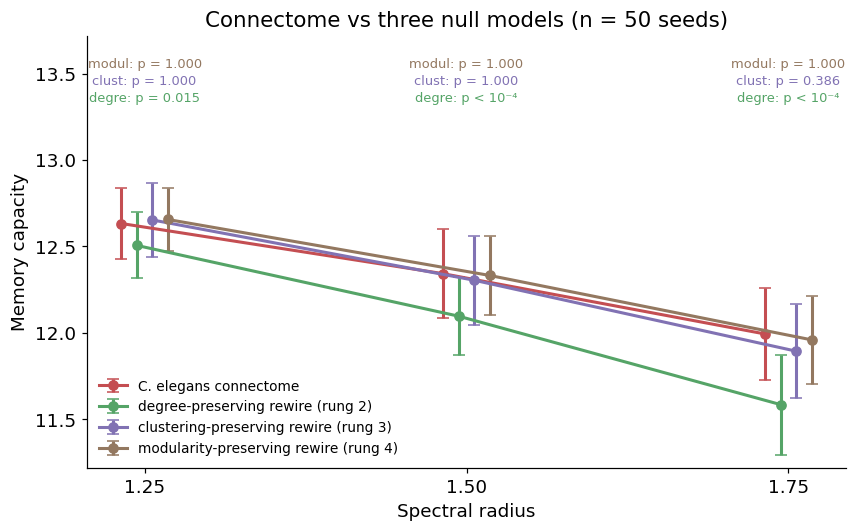

In [21]:
# Probe figure: mean MC ± std vs sr for all four conditions, with
# Holm-corrected p-values for each connectome-vs-null comparison at each sr.
v2c_palette = {
    "connectome":        "#c44e52",
    "degree_rewire":     "#55a467",
    "clustering_rewire": "#8172b3",
    "modularity_rewire": "#937860",
}
v2c_labels = {
    "connectome":        "C. elegans connectome",
    "degree_rewire":     "degree-preserving rewire (rung 2)",
    "clustering_rewire": "clustering-preserving rewire (rung 3)",
    "modularity_rewire": "modularity-preserving rewire (rung 4)",
}
v2c_x_offset = {
    "connectome":        -0.018,
    "degree_rewire":     -0.006,
    "clustering_rewire": +0.006,
    "modularity_rewire": +0.018,
}

fig, ax = plt.subplots(figsize=(8.0, 5.0))
for condition in probe_v2c_conditions:
    agg = (
        probe_v2c_df[probe_v2c_df["condition"] == condition]
        .groupby("spectral_radius")["mc"]
        .agg(["mean", "std"])
        .reindex(probe_v2c_spectral_radii)
        .reset_index()
    )
    ax.errorbar(
        agg["spectral_radius"] + v2c_x_offset[condition],
        agg["mean"],
        yerr=agg["std"],
        marker="o",
        capsize=4,
        lw=2,
        color=v2c_palette[condition],
        label=v2c_labels[condition],
    )

# Annotate Holm-corrected p-values per null per sr, stacked above the data.
y_max = probe_v2c_df["mc"].max()
y_step = 0.10
null_to_row = {n: r for r, n in enumerate(probe_v2c_nulls)}
for _, row in v2c_stats_df.iterrows():
    sr = row["spectral_radius"]
    null = row["null"]
    p = row["p_holm"]
    if p < 1e-4:
        label = f"{null[:5]}: p < 10⁻⁴"
    else:
        label = f"{null[:5]}: p = {p:.3f}"
    color = v2c_palette[null]
    ax.annotate(
        label,
        xy=(sr, y_max + 0.15 + null_to_row[null] * y_step),
        ha="center",
        va="bottom",
        fontsize=8.5,
        color=color,
    )

ax.set_xlabel("Spectral radius")
ax.set_ylabel("Memory capacity")
ax.set_title("Connectome vs three null models (n = 50 seeds)")
ax.set_xticks(probe_v2c_spectral_radii)
ax.set_ylim(top=y_max + 0.15 + len(probe_v2c_nulls) * y_step + 0.10)
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.savefig(PROBE_FIG_DIR / "probe_v2c.png", dpi=300, bbox_inches="tight")
plt.show()